In [4]:
import zipfile

zip_path='dog-vs-cat.zip'

with zipfile.ZipFile(zip_path,'r') as zip_ref:
  zip_ref.extractall('/content')


In [5]:
from tensorflow.keras.preprocessing import image

img=image.load_img("/content/animals/cat/00000-4122619873.png")
print(img.size)

(512, 512)


In [15]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D,MaxPooling2D,Flatten,Dense,Dropout
import matplotlib.pyplot as plt
import numpy as np

In [8]:
train_ds=tf.keras.preprocessing.image_dataset_from_directory(
    "/content/animals",
    validation_split=0.2,
    subset='training',
    seed=9,
    image_size=(128,128),
    batch_size=32
    )

Found 1000 files belonging to 2 classes.
Using 800 files for training.


In [9]:
val_ds=tf.keras.preprocessing.image_dataset_from_directory(
    "/content/animals",
    validation_split=0.2,
    subset='validation',
    seed=42,
    image_size=(128,128),
    batch_size=32
    )

Found 1000 files belonging to 2 classes.
Using 200 files for validation.


In [11]:
from tensorflow.keras.layers import Rescaling

normalization_layer=Rescaling(1./255)


train_data=train_ds.map(lambda x,y:(normalization_layer(x),y))
test_data=val_ds.map(lambda x,y:(normalization_layer(x),y))

['cat', 'dog']


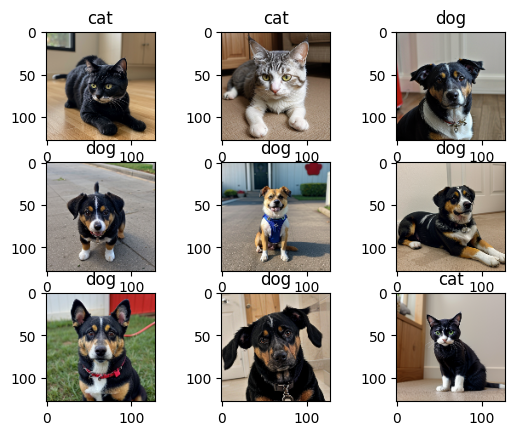

In [13]:
class_names=train_ds.class_names
print(class_names)


for images,labels in train_data.take(1):
  for i in range(9):
    plt.subplot(3,3,i+1)
    plt.imshow(images[i])
    plt.title(class_names[labels[i]])

plt.show()

In [16]:
model=Sequential()


model.add(Conv2D(32,(3,3),activation='relu',input_shape=(128,128,3)))
model.add(MaxPooling2D())

model.add(Conv2D(64,(3,3),activation='relu'))
model.add(MaxPooling2D())

model.add(Conv2D(128,(3,3),activation='relu'))
model.add(MaxPooling2D())

model.add(Conv2D(256,(3,3),activation='relu'))
model.add(MaxPooling2D())



model.add(Flatten())
model.add(Dense(512,activation='relu'))
model.add(Dropout(0.5))
model.add(Dense(1,activation='sigmoid'))



In [17]:
model.compile(optimizer='adam',loss='binary_crossentropy',metrics=['accuracy'])

In [18]:
model.fit(train_data,validation_data=(test_data),epochs=10,verbose=1)

Epoch 1/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 15s 256ms/step - accuracy: 0.5300 - loss: 0.7003 - val_accuracy: 0.4950 - val_loss: 0.6829
Epoch 2/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 7s 302ms/step - accuracy: 0.7200 - loss: 0.5440 - val_accuracy: 0.8150 - val_loss: 0.4418
Epoch 3/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 10s 300ms/step - accuracy: 0.8400 - loss: 0.3606 - val_accuracy: 0.8950 - val_loss: 0.2968
Epoch 4/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 6s 244ms/step - accuracy: 0.9062 - loss: 0.2375 - val_accuracy: 0.9050 - val_loss: 0.2677
Epoch 5/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 7s 297ms/step - accuracy: 0.9450 - loss: 0.1456 - val_accuracy: 0.9200 - val_loss: 0.1906
Epoch 6/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 9s 260ms/step - accuracy: 0.9650 - loss: 0.1021 - val_accuracy: 0.9400 - val_loss: 0.1439
Epoch 7/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 7s 275ms/step - accuracy: 0.9837 - loss: 0.0538 - val_accuracy: 0.9500 - val_loss: 0.1090
Epoch 8/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 11s 300ms/step - accuracy: 0.9775 - loss: 0.0635 - val_accuracy:

In [23]:
from tensorflow.keras.preprocessing import image

img=image.load_img("/content/animals/dog/00503-3846168665.png",target_size=(128,128))

img_array=image.img_to_array(img)
img_array=img_array/255.0
img_array=np.expand_dims(img_array,axis=0)



predictions=model.predict(img_array)

if predictions[0][0]>0.5:
  print("Dog")

else:
  print("Cat")



1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
Dog
